# Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import sys
sys.path.append('/workspaces/news-promotion-lp')

In [2]:
from src.data.preprocess import load_data, preprocess_features
from src.models.train import xgb_train
from src.models.predict import xgb_predict
from src.models.evaluate import evaluate_model
from src.optimization.lp_solver import extended_news_solver

print("✓ All imports successful")

✓ All imports successful


In [3]:
# Configurations
random_state=1234
test_size=0.2

# Load and preprocess data

In [4]:
df = load_data()

In [5]:
X_train, X_test, y_train, y_test = preprocess_features(
    df,
    test_size=test_size,
    random_state=random_state
)
print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

print("Extracting topic indicators...")
categories_features = [c for c in X_train.columns if c.startswith(' data_channel_is')]
categories_indicators = {
    col: X_train[col].values for col in categories_features
}

print(f"{len(categories_features)} categories found")

Train set: 31715 samples
Test set: 7929 samples
Extracting topic indicators...
7 categories found


# Model Implementation

In [6]:
import xgboost as xgb
params = {
    "objective": "reg:squarederror",
    "n_estimators": 100,
    "max_depth": 6,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": random_state
}
model = xgb.XGBRegressor(**params)
model.fit(X_train, y_train)
print("Model training complete")

Model training complete


In [7]:
y_pred = model.predict(X_test)
print("Prediction complete")
y_pred

Prediction complete


array([7.679593 , 6.875953 , 7.533406 , ..., 8.424739 , 7.0293493,
       7.305498 ], shape=(7929,), dtype=float32)

# ILP Solver

**Version 1:**
Run linear programming optimization for K=10 articles with diversity constraint of at least 7 categories represented:

In [8]:
lifestyle_indicator = categories_indicators.get(' data_channel_is_lifestyle', np.zeros(len(y_pred)))
entertainment_indicator = categories_indicators.get(' data_channel_is_entertainment', np.zeros(len(y_pred)))
bus_indicator = categories_indicators.get(' data_channel_is_bus', np.zeros(len(y_pred)))
socmed_indicator = categories_indicators.get(' data_channel_is_socmed', np.zeros(len(y_pred)))
tech_indicator = categories_indicators.get(' data_channel_is_tech', np.zeros(len(y_pred)))
world_indicator = categories_indicators.get(' data_channel_is_world', np.zeros(len(y_pred)))
other_indicator = categories_indicators.get(' data_channel_is_other', np.zeros(len(y_pred)))

selected_indices, status = extended_news_solver(
    shares=y_pred,
    lifestyle_indicator=lifestyle_indicator,
    entertainment_indicator=entertainment_indicator,
    bus_indicator=bus_indicator,
    socmed_indicator=socmed_indicator,
    tech_indicator=tech_indicator,
    world_indicator=world_indicator,
    other_indicator=other_indicator,
    K=10,
    diversity_lower_bound=7,
    solver_name="PULP_CBC_CMD",
    verbose=False
)
print(f"ILP solved: {status}")
lp_shares = y_pred[selected_indices].sum()
print(f"Optimal Shares by Linear Programming: {lp_shares} shares\n")
top10_shares = sum(sorted(y_pred, reverse=True)[:10])
print(f"Optimal Shares by Naive Top 10 Selection: {top10_shares} shares")
marginal_cost = lp_shares - top10_shares
print(f"Marginal Cost of Diversity: {marginal_cost} shares")

/home/codespace/.local/lib/python3.12/site-packages/pulp/pulp.py:1489: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


ILP solved: Optimal
Optimal Shares by Linear Programming: 88.95783996582031 shares

Optimal Shares by Naive Top 10 Selection: 89.2283706665039 shares
Marginal Cost of Diversity: -0.27053070068359375 shares


**Version 2:**
Run linear programming optimization for K=10 articles with diversity constraint ranging from 0 to 7:

In [9]:
df_sensitivity = []
for D in range(0, 8):
    selected_indices, status = extended_news_solver(
        shares=y_pred,
        lifestyle_indicator=lifestyle_indicator,
        entertainment_indicator=entertainment_indicator,
        bus_indicator=bus_indicator,
        socmed_indicator=socmed_indicator,
        tech_indicator=tech_indicator,
        world_indicator=world_indicator,
        other_indicator=other_indicator,
        K=10,
        diversity_lower_bound=D,
        solver_name="PULP_CBC_CMD",
        verbose=False
    )

    print(f"ILP solved: {status}")
    print(f"Selected {len(selected_indices)} articles")

    # Calculate results
    lp_shares = y_pred[selected_indices].sum()
    print(f"Total predicted shares: {lp_shares:.5f}")
    top10_shares = sum(sorted(y_pred, reverse=True)[:10])
    print(f"Optimal Shares by Naive Top 10 Selection: {top10_shares} shares")
    marginal_cost = lp_shares - top10_shares
    print(f"Marginal Cost of Diversity: {marginal_cost} shares")
    
    df_sensitivity.append({
        'diversity_lower_bound': D,
        'lp_shares': lp_shares,
        'naive_top10_shares': top10_shares,
        'n_selected': len(selected_indices),
        'marginal_cost': marginal_cost
    })

ILP solved: Optimal
Selected 10 articles
Total predicted shares: 89.22838
Optimal Shares by Naive Top 10 Selection: 89.2283706665039 shares
Marginal Cost of Diversity: 7.62939453125e-06 shares
ILP solved: Optimal
Selected 10 articles
Total predicted shares: 89.22838
Optimal Shares by Naive Top 10 Selection: 89.2283706665039 shares
Marginal Cost of Diversity: 7.62939453125e-06 shares
ILP solved: Optimal
Selected 10 articles
Total predicted shares: 89.22838
Optimal Shares by Naive Top 10 Selection: 89.2283706665039 shares
Marginal Cost of Diversity: 7.62939453125e-06 shares
ILP solved: Optimal
Selected 10 articles
Total predicted shares: 89.22838
Optimal Shares by Naive Top 10 Selection: 89.2283706665039 shares
Marginal Cost of Diversity: 7.62939453125e-06 shares
ILP solved: Optimal
Selected 10 articles
Total predicted shares: 89.22838
Optimal Shares by Naive Top 10 Selection: 89.2283706665039 shares
Marginal Cost of Diversity: 7.62939453125e-06 shares
ILP solved: Optimal
Selected 10 art

In [10]:
df_sensitivity = pd.DataFrame(df_sensitivity)
print("\nSensitivity Analysis Results:")
df_sensitivity


Sensitivity Analysis Results:


,diversity_lower_bound,lp_shares,naive_top10_shares,n_selected,marginal_cost
0,0,89.228378,89.228371,10,0.000008
1,1,89.228378,89.228371,10,0.000008
2,2,89.228378,89.228371,10,0.000008
3,3,89.228378,89.228371,10,0.000008
4,4,89.228378,89.228371,10,0.000008
5,5,89.228378,89.228371,10,0.000008
6,6,89.182526,89.228371,10,-0.045845
7,7,88.957840,89.228371,10,-0.270531


# Sensitivity Analysis

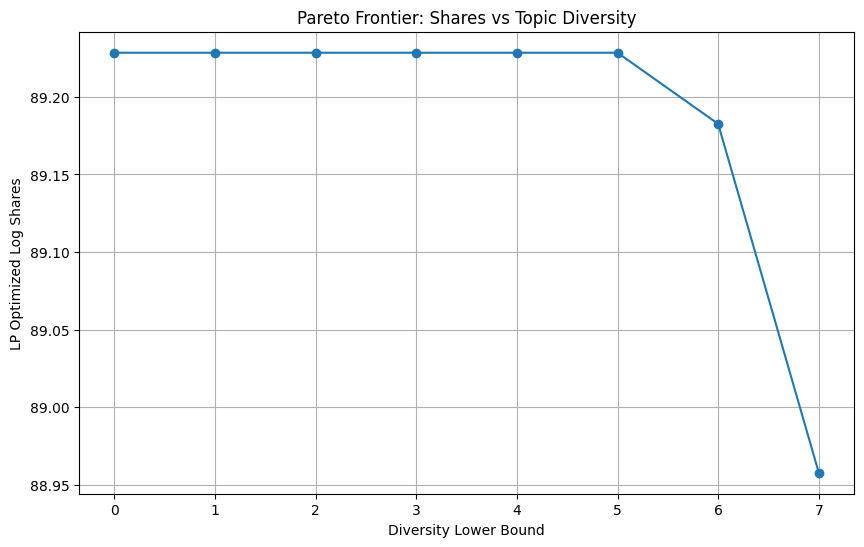

In [11]:
plt.figure(figsize=(10,6))
plt.plot(
    df_sensitivity["diversity_lower_bound"],
    df_sensitivity["lp_shares"],
    marker="o"
)

plt.xlabel("Diversity Lower Bound")
plt.ylabel("LP Optimized Log Shares")
plt.title("Pareto Frontier: Shares vs Topic Diversity")
plt.grid(True)
plt.show()

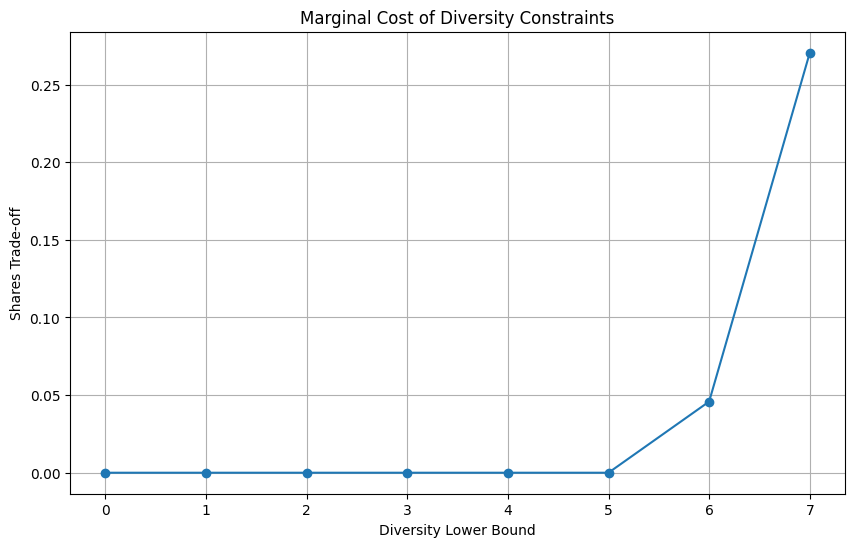

In [12]:
plt.figure(figsize=(10,6))
plt.plot(
    df_sensitivity["diversity_lower_bound"],
    np.abs(df_sensitivity["marginal_cost"]),
    marker="o"
)

plt.xlabel("Diversity Lower Bound")
plt.ylabel("Shares Trade-off")
plt.title("Marginal Cost of Diversity Constraints")
plt.grid(True)
plt.show()